In [2]:
!pip install -q --upgrade pip
!pip install -q qiskit==1.4.6
!pip install -q qiskit-aer==0.16.4
!pip install -q qiskit-algorithms==0.3.1
!pip install -q qiskit-nature==0.7.2
!pip install -q qiskit-nature-pyscf==0.4.0
!pip install -q pyscf==2.7.0
!pip install -q scipy matplotlib



# Task 2 — Ground-State VQE (UCCSD + Hardware-Efficient Ansatz)

**What this notebook does:**
1. Builds two ansatz circuits — UCCSD (chemistry-inspired) and a hardware-efficient ansatz (device-inspired)
2. Runs VQE with a classical optimizer (SLSQP) on the ethylene Hamiltonian from Task 1
3. Reports convergence, qubit count, and circuit depth for each — the two deliverables asked for

Input expected : `h` and `h_twisted`, the JW-mapped `SparsePauliOp` Hamiltonians for the equilibrium and twisted geometries.

In [3]:
import numpy as np
#from qiskit_ibm_runtime import QiskitRuntimeService, Session, EstimatorV2

from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

from qiskit.primitives import Estimator
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

##  Build the two ansätze

- **UCCSD**: starts from the Hartree-Fock reference state, then applies single/double excitation operators. Physically meaningful, but deeper circuits.
- **Hardware-efficient (EfficientSU2)**: alternating layers of single-qubit rotations + linear entanglement. No chemistry built in, but shallow and hardware-friendly.

Both need `num_spatial_orbitals` and `num_particles` explicitly, since we're working from a raw Hamiltonian rather than a qiskit-nature problem object.

In [28]:
def build_ansatz(num_spatial_orbitals, num_particles, mapper, type_anz="UCCSD", reps=2):

    n_qubits = 2 * num_spatial_orbitals
    if type_anz == "UCCSD":
        hf_state = HartreeFock(num_spatial_orbitals, num_particles, mapper)
        ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=hf_state)

        initial_point = np.zeros(ansatz.num_parameters)
    elif type_anz == "HEA":
        ansatz = EfficientSU2(2*num_spatial_orbitals, reps=reps, entanglement="linear")
        initial_point= np.random.default_rng(42).uniform(-0.1, 0.1, ansatz.num_parameters)
    else:
        raise ValueError("The Ansatw type 'type_anz' must be 'UCCSD' or 'HEA' ")

    return ansatz, initial_point

##  Run VQE and track convergence

The `callback` records the energy at every optimizer iteration — that trace is what "report convergence" asks for. Optimizer choice: **SLSQP**, a gradient-based classical optimizer that works well for the smooth, low-noise landscape of a statevector simulation.

In [26]:
def run_vqe(hamiltonian, ansatz, initial_point, optimizer=None):
    if optimizer == None:
      optimizer= SLSQP(maxiter=200)
    estimator = Estimator()

    convergence = []
    vqe_solver = VQE(
                    estimator, ansatz, optimizer,
                    initial_point= initial_point,
                    callback = lambda i, params, value, meta: convergence.append(value),
    )
    result = vqe_solver.compute_minimum_eigenvalue(hamiltonian)
    depth = ansatz.decompose(reps=3).depth()

    print(f"[{ansatz.name}] qubits = {ansatz.num_qubits} depth={depth} ")

    return {"energy": result.eigenvalue.real, "convergence": convergence, "num_qubits":ansatz.num_qubits, "depth":depth}


##  Load an example of Hamiltonians and run both ansätze on both geometries

Replace this cell with the `h` / `h_twisted` variables already in memory from your Task 1 notebook cells — shown here just so this notebook runs standalone.

In [29]:
from qiskit.quantum_info import SparsePauliOp

# --- Task 1 output
h = SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.67810865+0.j,  0.07683157+0.j, -0.07802605+0.j,  0.07683157+0.j,
 -0.07802605+0.j,  0.08418098+0.j,  0.12685108+0.j,  0.12720766+0.j,
  0.04302668+0.j,  0.04302668+0.j,  0.04302668+0.j,  0.04302668+0.j,
  0.12720766+0.j,  0.13086927+0.j,  0.08418098+0.j])
h_twisted = SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.65809122+0.j,  0.06206056+0.j, -0.0626729 +0.j,  0.06206056+0.j,
 -0.0626729 +0.j,  0.07940855+0.j,  0.12362153+0.j,  0.12451616+0.j,
  0.04510761+0.j,  0.04510761+0.j,  0.04510761+0.j,  0.04510761+0.j,
  0.12451616+0.j,  0.12784495+0.j,  0.07940855+0.j])
# --------------------------------------------------------------------------------

# Ethylene active space: 2 electrons in 2 orbitals -> 4 qubits
num_spatial_orbitals = 2
num_particles = (1,1) # (alpha, beta) electrons
mapper = JordanWignerMapper()

runs = {}
for geom_name, hamiltonian in [("equilibrium", h), ("twisted_90deg", h_twisted)]:
    print(f"\n==={geom_name}===")
    for type_anz in ("UCCSD", "HEA"):
        ansatz, ip = build_ansatz(num_spatial_orbitals, num_particles, mapper, type_anz=type_anz)
        runs[(geom_name, type_anz)] = run_vqe(hamiltonian, ansatz, ip)
        r = runs[(geom_name, type_anz)]
        print(f"{geom_name:14s} | {type_anz:5s} | qubits={r['num_qubits']} | "
              f"depth={r['depth']:3d} | energy={r['energy']:.6f} Ha")




===equilibrium===


/tmp/ipykernel_3095/2689051145.py:4: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


[EvolvedOps] qubits = 4 depth=112 
equilibrium    | UCCSD | qubits=4 | depth=112 | energy=-1.197488 Ha


/tmp/ipykernel_3095/2689051145.py:4: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


[EfficientSU2] qubits = 4 depth=11 
equilibrium    | HEA   | qubits=4 | depth= 11 | energy=-1.197487 Ha

===twisted_90deg===


/tmp/ipykernel_3095/2689051145.py:4: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


[EvolvedOps] qubits = 4 depth=112 
twisted_90deg  | UCCSD | qubits=4 | depth=112 | energy=-1.122352 Ha


/tmp/ipykernel_3095/2689051145.py:4: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator = Estimator()


[EfficientSU2] qubits = 4 depth=11 
twisted_90deg  | HEA   | qubits=4 | depth= 11 | energy=-1.122352 Ha


##  Convergence plot

Energy vs. optimizer iteration for both ansätze, at the equilibrium geometry.

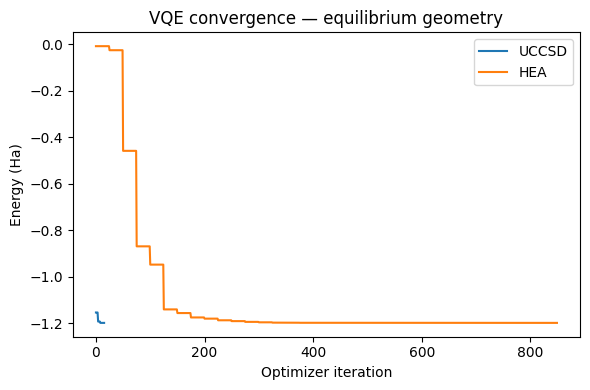

In [31]:
plt.figure(figsize=(6, 4))
for type_anz in ("UCCSD", "HEA"):
    conv = runs[("equilibrium", type_anz)]["convergence"]
    plt.plot(conv, label=type_anz)
plt.xlabel("Optimizer iteration")
plt.ylabel("Energy (Ha)")
plt.title("VQE convergence — equilibrium geometry")
plt.legend()
plt.tight_layout()
plt.show()

## Summary table — qubit count and circuit depth

This table is the direct answer to "report convergence, qubit count, and circuit depth for each ansatz." Convergence is summarized here as number of iterations to converge and final energy; the full trace is the plot above.

In [32]:
rows = []
for (geom_name, type_anz), r in runs.items():
    rows.append({
        "geometry": geom_name,
        "ansatz": type_anz,
        "num_qubits": r["num_qubits"],
        "circuit_depth": r["depth"],
        "iterations_to_converge": len(r["convergence"]),
        "final_energy_Ha": round(r["energy"], 6),
    })

summary = pd.DataFrame(rows)
summary

,geometry,ansatz,num_qubits,circuit_depth,iterations_to_converge,final_energy_Ha
0,equilibrium,UCCSD,4,112,16,-1.197488
1,equilibrium,HEA,4,11,850,-1.197487
2,twisted_90deg,UCCSD,4,112,16,-1.122352
3,twisted_90deg,HEA,4,11,851,-1.122352
